## Dataset Overview

In [27]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
import joblib

%matplotlib inline
sns.set(style="whitegrid", font_scale=1.1)

# Paths
CHEATER_PATH = "../data/full_dataset/with_cheater_present"
NON_CHEATER_PATH = "../data/context_windows_512/not_cheater"
RESULTS_PATH = "../results"
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
RESULTS_DIR = os.path.join(BASE_DIR, "results")

rf_path = os.path.join(RESULTS_DIR, "random_forest_model.pkl")
lr_path = os.path.join(RESULTS_DIR, "logistic_regression_model.pkl")
X_test_path = os.path.join(RESULTS_DIR, "X_test.csv")
y_test_path = os.path.join(RESULTS_DIR, "y_test.csv")


## Load Sample Data

In [28]:
def load_sample_data(n_files=5, rows_per_file=5000):
    cheater_files = [os.path.join(CHEATER_PATH, f) for f in os.listdir(CHEATER_PATH) if f.endswith(".parquet")][:n_files]
    non_cheater_files = [os.path.join(NON_CHEATER_PATH, f) for f in os.listdir(NON_CHEATER_PATH) if f.endswith(".parquet")][:n_files]

    dfs = []
    for path, label in [(cheater_files, 1), (non_cheater_files, 0)]:
        for f in path:
            try:
                table = pq.read_table(f)
                df = table.to_pandas().head(rows_per_file)
                df["is_cheater"] = label
                dfs.append(df)
            except Exception as e:
                print(f"Skipped {f} due to error: {e}")
    df = pd.concat(dfs, ignore_index=True)
    return df

df = load_sample_data(n_files=5, rows_per_file=5000)
print(f"Loaded dataset shape: {df.shape}")
df.head()

Loaded dataset shape: (27560, 272)


,inventory,usercmd_input_history,inventory_as_ids,approximate_spotted_by,aim_punch_angle_vel,aim_punch_angle,active_weapon_ammo,item_def_idx,weapon_quality,entity_lvl,...,map_ancient,map_vertigo,map_anubis,map_office,map_overpass,map_basalt,map_edin,map_italy,map_thera,map_mills
0,"[knife_t, Glock-18]",[],"[59, 4]",[],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",20.0,4.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[knife_t, Glock-18]",[],"[59, 4]",[],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",0.0,59.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[knife, USP-S]",[],"[42, 61]",[],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",0.0,42.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[knife, USP-S]",[],"[42, 61]",[],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",0.0,42.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[knife_t, Glock-18]",[],"[59, 4]",[Player_2],"[-22.530092239379883, 4.745694637298584, 0.0]","[-4.567562580108643, 0.11503522843122482, 4.16...",17.0,4.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Visualizations

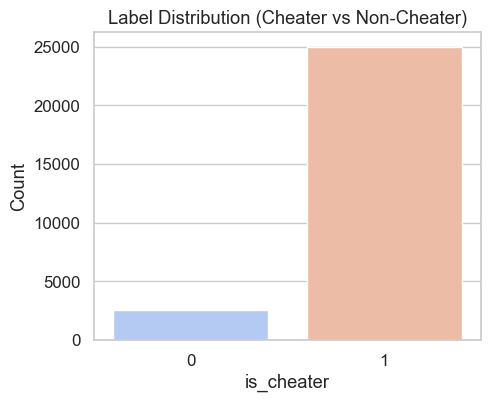

In [20]:
plt.figure(figsize=(5,4))
sns.countplot(x="is_cheater", data=df, palette="coolwarm", hue="is_cheater", legend=False)
plt.title("Label Distribution (Cheater vs Non-Cheater)")
plt.xlabel("is_cheater")
plt.ylabel("Count")
plt.show()

<Figure size 1200x500 with 0 Axes>

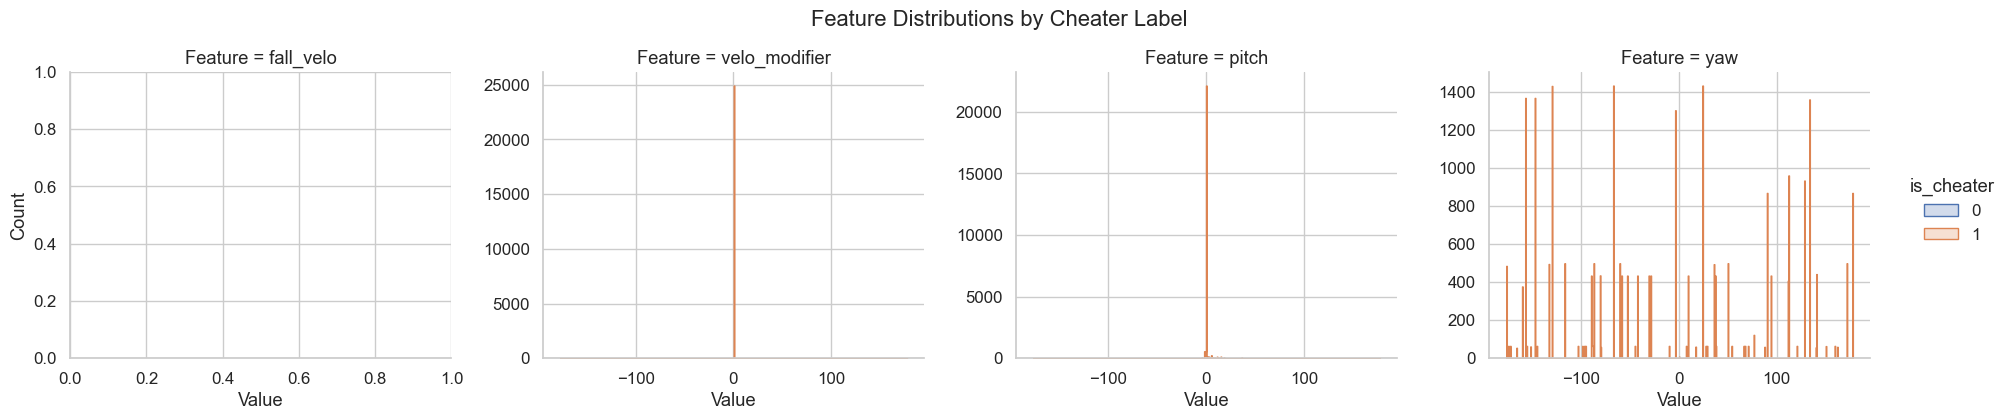

In [29]:
# Histogram
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_subset = [col for col in num_cols if any(k in col.lower() for k in ["yaw", "pitch", "vel"])]
df_melt = df.melt(value_vars=feature_subset[:4], id_vars="is_cheater", var_name="Feature", value_name="Value")

plt.figure(figsize=(12,5))
sns.displot(
    df_melt,
    x="Value",
    hue="is_cheater",
    col="Feature",
    kind="hist",
    element="step",
    multiple="layer",
    common_norm=False,
    facet_kws={"sharex": False, "sharey": False},
    height=4,
    aspect=1.2
)
plt.suptitle("Feature Distributions by Cheater Label", y=1.05)
plt.show()


In [30]:
rf_path = os.path.join(RESULTS_PATH, "random_forest_model.pkl")
lr_path = os.path.join(RESULTS_PATH, "logistic_regression_model.pkl")
X_test_path = os.path.join(RESULTS_PATH, "X_test.csv")
y_test_path = os.path.join(RESULTS_PATH, "y_test.csv")

if os.path.exists(rf_path) and os.path.exists(lr_path) and os.path.exists(X_test_path) and os.path.exists(y_test_path):
    rf = joblib.load(rf_path)
    lr = joblib.load(lr_path)
    X_test = pd.read_csv(X_test_path)
    y_test = pd.read_csv(y_test_path).squeeze()

    y_pred_rf = rf.predict(X_test)
    y_pred_lr = lr.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:,1]
    y_prob_lr = lr.predict_proba(X_test)[:,1]

    # Confusion matrices
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=ax[0], colorbar=False)
    ax[0].set_title("Random Forest")
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=ax[1], colorbar=False)
    ax[1].set_title("Logistic Regression")
    plt.suptitle("Confusion Matrices", y=1.02)
    plt.tight_layout()
    plt.show()

    # ROC Curves
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc(fpr_rf,tpr_rf):.3f})")
    plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc(fpr_lr,tpr_lr):.3f})")
    plt.plot([0,1],[0,1],"--",color="gray")
    plt.title("ROC Curve Comparison")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # Precision-Recall Curves
    p_rf, r_rf, _ = precision_recall_curve(y_test, y_prob_rf)
    p_lr, r_lr, _ = precision_recall_curve(y_test, y_prob_lr)
    plt.figure(figsize=(6,5))
    plt.plot(r_rf, p_rf, label=f"RF (AP={average_precision_score(y_test,y_prob_rf):.3f})")
    plt.plot(r_lr, p_lr, label=f"LR (AP={average_precision_score(y_test,y_prob_lr):.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision-Recall Curve Comparison")
    plt.legend()
    plt.show()

    # Summary Table
    report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
    report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
    summary = pd.DataFrame({
        "Model": ["Random Forest", "Logistic Regression"],
        "Precision": [report_rf["weighted avg"]["precision"], report_lr["weighted avg"]["precision"]],
        "Recall": [report_rf["weighted avg"]["recall"], report_lr["weighted avg"]["recall"]],
        "F1": [report_rf["weighted avg"]["f1-score"], report_lr["weighted avg"]["f1-score"]],
        "AUC": [auc(fpr_rf,tpr_rf), auc(fpr_lr,tpr_lr)]
    })
    display(summary)

In [32]:
rf = joblib.load(rf_path)
lr = joblib.load(lr_path)
X_test = pd.read_csv(X_test_path)
y_test = pd.read_csv(y_test_path).squeeze()

# Predictions
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_lr = lr.predict_proba(X_test)[:, 1]

/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/giannadelorenzo/Documents/GitHub/ds340w_GiannaCayla/.venv/lib/python3.11/site-packa

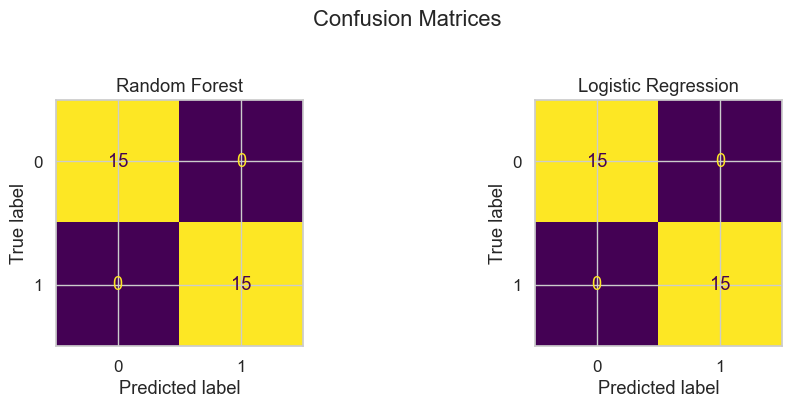

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Random Forest")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Logistic Regression")
plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

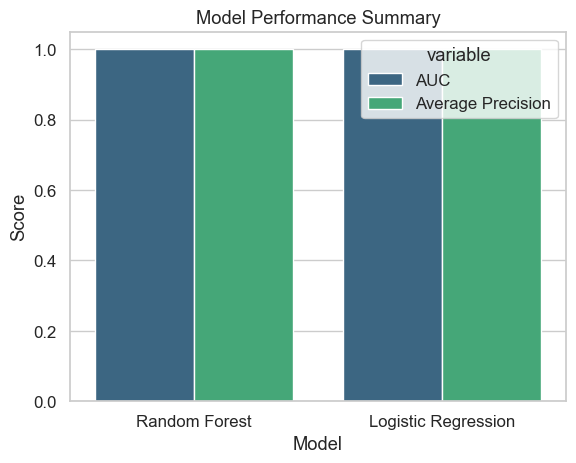

In [38]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
ap_rf = average_precision_score(y_test, y_prob_rf)
ap_lr = average_precision_score(y_test, y_prob_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)
summary = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "AUC": [auc_rf, auc_lr],
    "Average Precision": [ap_rf, ap_lr]
})

sns.barplot(data=summary.melt(id_vars="Model"), x="Model", y="value", hue="variable", palette="viridis")
plt.title("Model Performance Summary")
plt.ylabel("Score")
plt.show()

/var/folders/0h/mcgbb4750lsc9nt42mnstlqw0000gn/T/ipykernel_85399/2146927404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10), y=importances.head(10).index, palette="coolwarm")


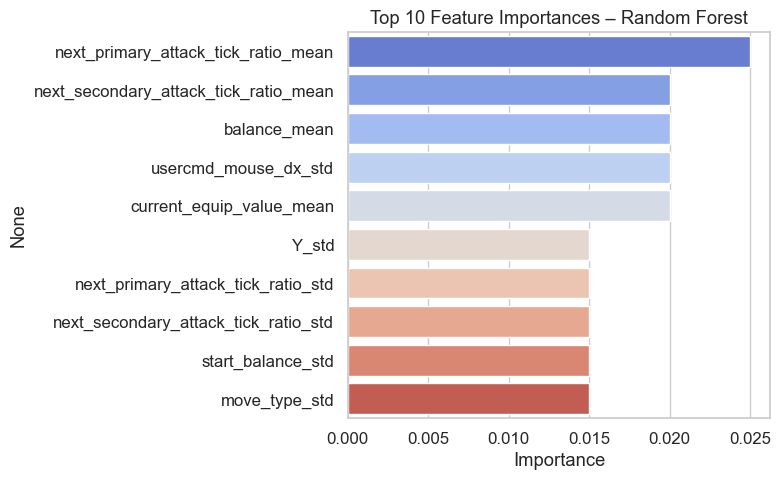

In [ ]:
if hasattr(rf, "feature_importances_"):
    importances = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.head(10), y=importances.head(10).index, palette="coolwarm", )
    plt.title("Top 10 Feature Importances – Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()